In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [3]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [4]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [5]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [6]:
from figModel import *

# Gain, Lr and Lm characterization

<br><br><br><br><br><br>
<img src  = "figs/uneLLCtank.png">

## Table of contents

## Single pulse setup

### Setup

For this test, we will use the same MOSFETs, driver, and microcontroller as those used in the LLC DC‑DC converter. This test will serve as the reference for inductance characterization.

In [7]:
fig_counter=One_figure_with_captions(fig_counter, img1="Setup1.png"
                                     , caption1="Single pulse setup (simplified schematic)",
                                     first_part_path="figs/", 
                                     width=19)

In the above simplified schematic, the DC link capacitor of 4 µF is not represented.
<br>The Ton is controlled by the STM32F1 firmware.

**Formulas used during preprocessing**

* $
\text{Magnetic Flux:} \qquad 
\phi = \frac{1}{N}\int V(t)\,\mathrm{d}t
$

* $
\text{Magnetic Flux Density:} \qquad
B = \frac{\phi}{A_e}
$

* $
\text{Magnetic Field Strength:} \qquad
H = \frac{N\,I_L}{l_e}
$


### Lm Without air gap

In this test, we will use the transformer choke with a PCB winding (4 turns), leaving the secondary open to characterize the Lm inductance. No air gap is used. 
<br>The main objective is to compare the measured inductance with the datasheet value of this choke.

In [8]:
fig_counter=One_figure_with_captions(fig_counter, img1="2025-11-30_13-26-08-603.png"
                                     , caption1="Oscilloscope screenshot, CH1 = V_L, CH2 = I_L",
                                     first_part_path="./03_Single_pulse_method/97V_Lm_without_Gape/", 
                                     width=17)

The plot shows the current and voltage data with zero correction at the beginning

In [9]:
parentpath= "./03_Single_pulse_method/97V_Lm_without_Gape/"

In [10]:
df = pd.read_csv(parentpath+"2025-11-30_13-26-08-603.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe
Ts = df.Ts.values[0]
#df.head()

In [11]:
v0=vds[:200].mean()
i0= iD[:200].mean()
#print(v0, i0)
vds2= vds-v0
id2=iD-i0

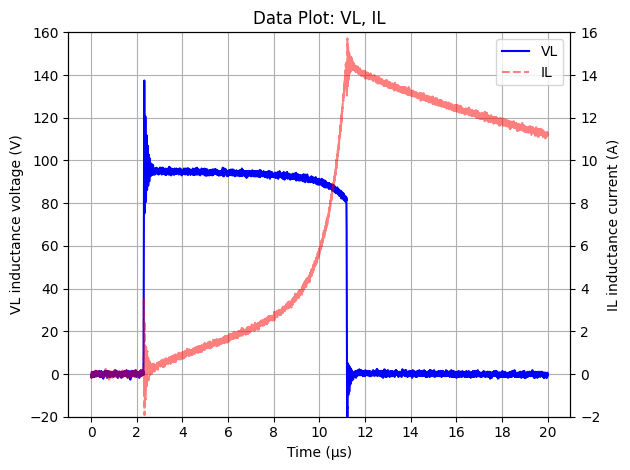

In [12]:
fig, ax1 = plt.subplots()
t = 1e6 * df.time.values
t = t - t[0]
line1, = ax1.plot(t, vds2, label='VL', c="b")
ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('VL inductance voltage (V)')

ax2 = ax1.twinx()
line2, = ax2.plot(t, id2, linestyle='--', label='IL', c="r", alpha=0.5)
ax2.set_ylabel('IL inductance current (A)')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

ax1.set_ylim([-20, 160])
ax2.set_ylim([-2, 16])
ax2.set_yticks(np.linspace(-2, 16, 10))  
ax1.set_yticks(np.linspace(-20, 160, 10))  

# X-axis ticks - simple approach
#ax1.set_xlim(0, 10)
ax1.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.title("Data Plot: VL, IL")
ax1.grid()
plt.tight_layout()
plt.show()

In [13]:
idx_rise = trigger (vds, transition= "rise")
idx_fall= trigger (vds, transition= "fall")
#len(idx_rise), len(idx_fall)

In [14]:
a="""
fig, axs = plt.subplots(1,2, figsize= (10,5))
axs[0].plot(vds2)
if len(idx_rise): 
    axs[0].plot(idx_rise, len(idx_rise)*[40], marker= "x")
if len(idx_fall): 
    axs[0].plot(idx_fall, len(idx_fall)*[60], marker= "x")
axs[1].plot(id2)
axs[0].grid()
axs[1].grid()"""

See fromulas above. 

For more information, see the [datasheet](https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_102_20_38.pdf)

In [15]:
%%render 
A_e = 534.2 # mm2
l_e = 121.2  # mm
AL_nom = 9600 # nH/N2

<IPython.core.display.Latex object>

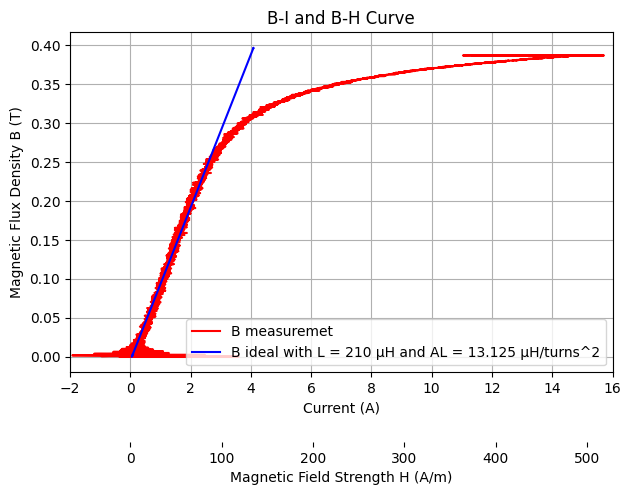

In [16]:
# https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_102_20_38.pdf
# ELP 102/20/38 with I 102/7/38
# Ae = 534.2 mm2
Ae = 534.2e-6
# le = 121.2 mm
le = 121.2e-3
integV= np.cumsum(vds2)*Ts
N= 4
flux = integV/N
B = flux /Ae
H= N*id2/le



L = 210e-6
Lcal = L
Bcal = L*id2/(Ae*N)
AL = L/N**2 # L= AL *N**2 
ALcal = AL

ALnom = 9600
error =100*(AL*1e9-ALnom) /ALnom
#print ("AL (nH)= ", AL*1e9, "error %", error)


msk = (Bcal < 0.4)  & (id2 >0)


# Plot B vs Current with secondary x-axis for H (both at bottom)
fig, ax1 = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.2)

ax1.plot(id2, B, label= "B measuremet", c="r")
ax1.set_xlabel('Current (A)')
ax1.set_ylabel('Magnetic Flux Density B (T)')
ax1.grid(True)
ax1.set_xlim([-2,16])

i00=0.05
ax1.plot(id2[msk]+i00,Bcal[msk], label= f"B ideal with L = {Lcal*1e6:.0f} µH and AL = {1e6*ALcal:.3f} µH/turns^2",
         c="b")
ax1.legend()

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim()[0] * N / le, ax1.get_xlim()[1] * N / le)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 50))
ax2.set_xlabel('Magnetic Field Strength H (A/m)')
ax2.set_frame_on(False)

plt.title('B-I and B-H Curve')
plt.show()

**Comparison between the measured value and the typical value provided in the datasheet:**

In [17]:
%%render 
Al_Measur = 13125 # nH/turns2 : see the above estimation 
Al_nominal = 9600 # nH/turns2 : see the datasheet
Error_AL = 100* (Al_Measur -Al_nominal) /Al_nominal # \%


<IPython.core.display.Latex object>

The measured error (36.7%) exceeds the datasheet specification of 25%.

In [18]:
from math import *

In [19]:
mu_0 = 4 * pi * 1e-7

Estimating the inductance for a 100 µm air gap (2×50 µm) using the nominal AL value from the datasheet.

In [20]:
%%render 
Ae_mm2 = 534.2 # see the datasheet 
# Ae = Ae_mm2 * 1e-6
lg_um = 100# µm 2x50 µm
lg = 1e-6*lg_um #0.10e-3  Total gap 2 * 0.05 mm
Al_nom = Al_nominal * 1e-9
# Calculate new AL using the reluctance sum formula:
# 1/AL_gapped = 1/AL_nom + lg / (mu0 * Ae)
AL_gap_nH1= 1e9 / ( (1/ Al_nom) + ( lg  / ( mu_0 * Ae_mm2  * 1e-6 ))) # nH / turns 2
#AL_gap_nH= 1e9 * AL_gapped # nH / turns 2
Lnew1 = 1e-3 * N**2*AL_gap_nH1 # µH 
# Lnew_uH = 1e6 * Lnew  # µH 

<IPython.core.display.Latex object>

Estimating the inductance for a 100 µm air gap (2×50 µm) using the measured AL value

In [21]:
%%render 

# Calculate new AL using the reluctance sum formula:
# 1/AL_gapped = 1/AL_nom + lg / (mu0 * Ae)
AL_gap_nH2= 1e9 / ( (1e9/ Al_Measur) + ( lg  / ( mu_0 * Ae_mm2  * 1e-6 ))) # nH / turns 2
#AL_gap_nH= 1e9 * AL_gapped # nH / turns 2
Lnew2 = 1e-3 * N**2*AL_gap_nH2 # µH 
# Lnew_uH = 1e6 * Lnew  # µH 

<IPython.core.display.Latex object>

Calculating the error between the datasheet air‑gapped value and the measured AL value :

In [22]:
%%render 
Error = 100* (AL_gap_nH2  -AL_gap_nH1) / AL_gap_nH1 # \%

<IPython.core.display.Latex object>

The dispersion error with the air gap is 12.5%, representing roughly one-third of the original 36.7% dispersion without an air gap.

### Lm With Air gap

We will use 0.050 mm thick Kapton to form the air gap, resulting in a total air gap of 2×50 µm = 100 µm.

In [23]:
# 10MM, Brown, 33M, 0.05MM
fig_counter=One_figure_with_captions(fig_counter, img1="KAPTON1.png"
                                     , caption1="0.05 mm Kapton layer as transformer air gap, total air gap 0.1mm",
                                     first_part_path="./figs/", 
                                     width=14)

In [24]:
fig_counter=One_figure_with_captions(fig_counter, img1="2025-11-30_14-13-12-680.png"
                                     , caption1="Oscilloscope screenshot, CH1 = V_L, CH2 = I_L",
                                     first_part_path="./03_Single_pulse_method/97V_Lm_Gap_0_1mm/", 
                                     width=14)

In [25]:
# <img src = "./03_Single_pulse_method/97V_Lm_Gap_0_1mm/2025-11-30_14-13-12-680.png">

In [26]:
parentpath= "./03_Single_pulse_method/97V_Lm_Gap_0_1mm/"

In [27]:
df = pd.read_csv(parentpath+"2025-11-30_14-13-12-680.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe
Ts = df.Ts.values[0]
#df.head()

In [28]:
v0=vds[:200].mean()
i0= iD[:200].mean()
#print(v0, i0)
vds2= vds-v0
id2=iD-i0

In [29]:
idx_rise = trigger (vds, transition= "rise")
idx_fall= trigger (vds, transition= "fall")
#len(idx_rise), len(idx_fall)

The plot shows the current and voltage data with zero correction at the beginning

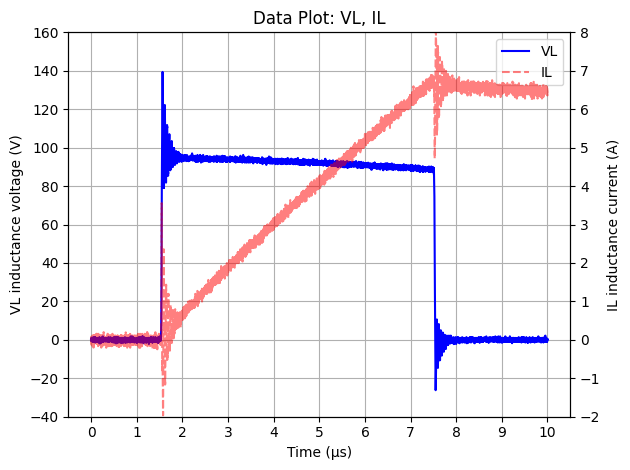

In [30]:
fig, ax1 = plt.subplots()
t = 1e6 * df.time.values
t = t - t[0]
line1, = ax1.plot(t, vds2, label='VL', c="b")
ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('VL inductance voltage (V)')

ax2 = ax1.twinx()
line2, = ax2.plot(t, id2, linestyle='--', label='IL', c="r", alpha=0.5)
ax2.set_ylabel('IL inductance current (A)')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

ax1.set_ylim([-40, 160])
ax2.set_ylim([-2, 8])
ax2.set_yticks(np.linspace(-2, 8, 11))  
ax1.set_yticks(np.linspace(-40, 160, 11))  

# X-axis ticks - simple approach
#ax1.set_xlim(0, 10)
ax1.xaxis.set_major_locator(plt.MultipleLocator(1))

ax1.grid()
plt.title("Data Plot: VL, IL")
plt.tight_layout()
plt.show()

In [31]:
# See fromulas above. 

# For more information, see the [datasheet](https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_102_20_38.pdf)

In [32]:
#%%render 
#A_e = 534.2 # mm2
#l_e = 121.2  # mm
#AL_nom = 9600 # nH/N2

In [33]:
# https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_102_20_38.pdf
# ELP 102/20/38 with I 102/7/38
# Ae = 534.2 mm2
Ae = 534.2e-6
# le = 121.2 mm
le = 121.2e-3
integV= np.cumsum(vds2)*Ts
N= 4
flux = integV/N
B = flux /Ae
H= N*id2/le
#fig, axs = plt.subplots(1,2, figsize= (10,5))
#plt.plot

L = 83e-6
Bcal = L*id2/(Ae*N)
AL = L/N**2 # L= AL *N**2 
Lcal=L
ALcal =AL

#ALnom = 9600
#error =100*(AL*1e9-ALnom) /ALnom
#print ("AL (nH)= ", AL*1e9, "error %", error)
_="""
axs[0].plot(id2,B)
msk = (Bcal < 0.4)  & (id2 >0)
axs[0].plot(id2[msk],Bcal[msk])
axs[1].plot(H, B)
axs[0].grid()
axs[1].grid()"""

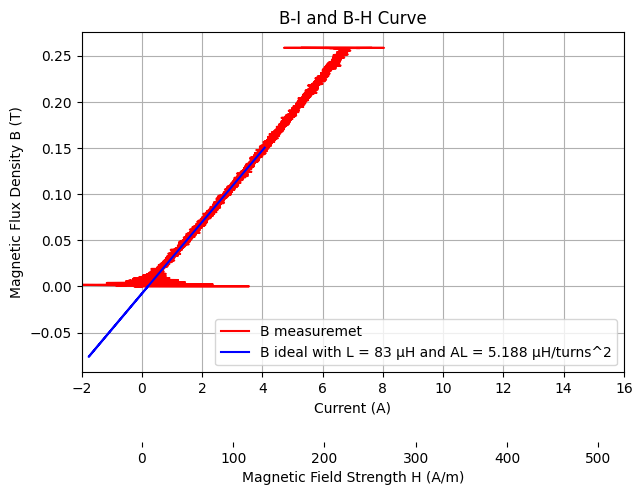

In [34]:

# Plot B vs Current with secondary x-axis for H (both at bottom)
fig, ax1 = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.2)

ax1.plot(id2, B, label= "B measuremet", c="r")
ax1.set_xlabel('Current (A)')
ax1.set_ylabel('Magnetic Flux Density B (T)')
ax1.grid(True)
ax1.set_xlim([-2,16])

i00=0.2
ax1.plot(id2[msk]+i00,Bcal[msk], label= f"B ideal with L = {Lcal*1e6:.0f} µH and AL = {1e6*ALcal:.3f} µH/turns^2",
         c="b")
ax1.legend()

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim()[0] * N / le, ax1.get_xlim()[1] * N / le)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 50))
ax2.set_xlabel('Magnetic Field Strength H (A/m)')
ax2.set_frame_on(False)

plt.title('B-I and B-H Curve')
plt.show()

**Estimating the real air gap**

The characterized inductance is 83 µH, while the estimated value using the measured AL and the nominal air gap is 71 µH. Let's now estimate the actual air gap.

In [35]:
%%render 
AL_MeasNoAirGap  = 13125 # nH/Turns2
AL_MeasAirGap = 83*1e3/N**2 # nH/Turns2

<IPython.core.display.Latex object>

In [36]:
%%render 
lg = 1e3 * mu_0 * Ae * 1e9*(1/AL_MeasAirGap - 1/AL_MeasNoAirGap) # mm
lg_nom = 0.1 # mm
lg_error = 100* (lg -lg_nom) /lg_nom # \%

<IPython.core.display.Latex object>

the air gap error of ~22% (100µm) is acceptable for kapton air gap without no control of the assembling pression

**Conclusion**
<br>
The primary magnetic inductance reference value for this project's transformer will be set to **83 µH**.

### Lr Without air gap

In this test, we will use the resonant inductance choke with a PCB winding (8 turns), with no air gap is used. 
<br>The main objective is to compare the measured inductance with the datasheet value of this choke.

In [37]:
fig_counter=One_figure_with_captions(fig_counter, img1="2025-11-30_14-58-37-525.png"
                                     , caption1="Oscilloscope screenshot, CH1 = V_L, CH2 = I_L",
                                     first_part_path="./03_Single_pulse_method/97V_Lr_withoutAirGap/", 
                                     width=17)

In [38]:
df = pd.read_csv("./03_Single_pulse_method/97V_Lr_withoutAirGap/2025-11-30_14-58-37-525.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe
Ts = df.Ts.values[0]
#df.head()

In [39]:
v0=vds[:200].mean()
i0= iD[:200].mean()
#print(v0, i0)
vds2= vds-v0
id2=iD-i0

The plot shows the current and voltage data with zero correction at the beginning

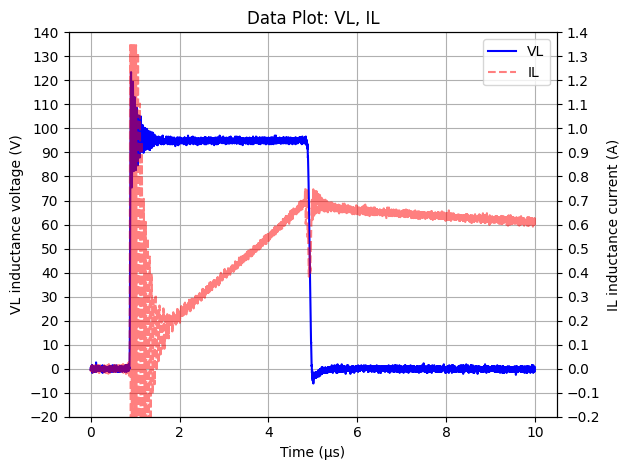

In [40]:
fig, ax1 = plt.subplots()
t = 1e6 * df.time.values
t = t - t[0]
line1, = ax1.plot(t, vds2, label='VL', c="b")
ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('VL inductance voltage (V)')

ax2 = ax1.twinx()
line2, = ax2.plot(t, id2, linestyle='--', label='IL', c="r", alpha=0.5)
ax2.set_ylabel('IL inductance current (A)')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')
Imin, Imax=-0.2,1.4
Vmin,Vmax=-20,140
ax1.set_ylim([Vmin,Vmax])
ax2.set_ylim([Imin, Imax])
N=int((Vmax-Vmin)/10)+1
ax2.set_yticks(np.linspace(Imin, Imax, N))  
ax1.set_yticks(np.linspace(Vmin,Vmax, N))  

# X-axis ticks - simple approach
#ax1.set_xlim(0, 10)
ax1.xaxis.set_major_locator(plt.MultipleLocator(2))

ax1.grid()
plt.title("Data Plot: VL, IL")
plt.tight_layout()
plt.show()

See fromulas above. 

For more information, see the [ELP 43/10/28 with ELP 43/10/28 N87 datasheet](https://product.tdk.com/system/files/dam/doc/product/ferrite/ferrite/ferrite-core/data_sheet/80/db/fer/elp_43_10_28.pdf)

In [41]:
%%render 
A_e = 225 # mm2
l_e = 61.6 # mm
AL_nom = 7300 # nH/N2

<IPython.core.display.Latex object>

In [42]:
# https://product.tdk.com/system/files/dam/doc/product/ferrite/ferrite/ferrite-core/data_sheet/80/db/fer/elp_43_10_28.pdf?ref_disty=mouser
# Combination: ELP 43/10/28 with ELP 43/10/28 N87
# Ae = 225 mm2
Ae = 225e-6
# le = 61.6 mm
le = 61.6e-3
AL = 7300e-9 #nH +/-25%
N = 8
integV= np.cumsum(vds2)*Ts


flux = integV/N
B = flux /Ae
H= N*id2/le

plt.plot

L = 580e-6
Bcal = L*id2/(Ae*N)
AL = L/N**2 # L= AL *N**2 
Lcal=L
ALcal=AL

#ALnom = 9600
#error =100*(AL*1e9-ALnom) /ALnom
#print ("AL (nH)= ", AL*1e9, "error %", error)


In [43]:
a="""
fig, axs = plt.subplots(1,2, figsize= (10,5))
axs[0].plot(vds2)
if len(idx_rise): 
    axs[0].plot(idx_rise, len(idx_rise)*[40], marker= "x")
if len(idx_fall): 
    axs[0].plot(idx_fall, len(idx_fall)*[60], marker= "x")
axs[1].plot(id2)
axs[0].grid()
axs[1].grid()"""

In [44]:
#Bcal<B.max()

In [45]:
#Bcal

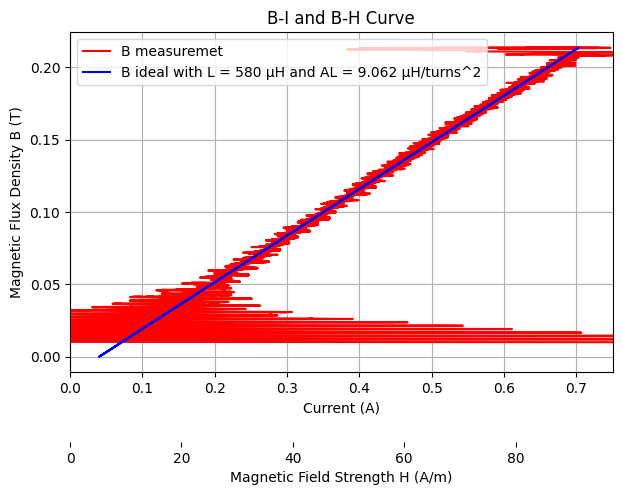

In [46]:


# Plot B vs Current with secondary x-axis for H (both at bottom)
fig, ax1 = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.2)
mask= B>0.01
ax1.plot(id2[mask], B[mask], label= "B measuremet", c="r")
ax1.set_xlabel('Current (A)')
ax1.set_ylabel('Magnetic Flux Density B (T)')
ax1.grid(True)
ax1.set_xlim([0,0.75])

i00=0.04
msk =Bcal<B.max()
msk =(Bcal>B.min()) & msk
#msk =Bcal<0.01
ax1.plot(id2[msk]+i00,Bcal[msk], label= f"B ideal with L = {Lcal*1e6:.0f} µH and AL = {1e6*ALcal:.3f} µH/turns^2",c="b")
ax1.legend()

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim()[0] * N / le, ax1.get_xlim()[1] * N / le)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 50))
ax2.set_xlabel('Magnetic Field Strength H (A/m)')
ax2.set_frame_on(False)

plt.title('B-I and B-H Curve')
plt.show()

**Comparison between the measured value and the typical value provided in the datasheet:**

In [47]:
%%render 
Al_Measur = 1e9*ALcal # nH/turns2 : see the above estimation 
Al_nominal = 7300 # nH/turns2 : see the datasheet
Error_AL = 100* (Al_Measur -Al_nominal) /Al_nominal # \%


<IPython.core.display.Latex object>

The measured error (24.1%) is in the the datasheet specification (+/-25%).

In [48]:
from math import *

In [49]:
mu_0 = 4 * pi * 1e-7

Estimating the inductance for a 800 µm (2x2×0.2 mm) air gap using the nominal AL value from the datasheet.

* 2x2×0.2 mm: We will use two layers, each with a thickness of 0.2 mm

In [50]:
%%render 
Ae_mm2 = 225 # see the datasheet 
# Ae = Ae_mm2 * 1e-6
lg_mm = 0.2 *2 *2 #  mm
lg = 1e-3*lg_mm #0.10e-3  Total gap 2 * 0.05 mm
Al_nom = Al_nominal * 1e-9
# Calculate new AL using the reluctance sum formula:
# 1/AL_gapped = 1/AL_nom + lg / (mu0 * Ae)
AL_gap_nH1= 1e9 / ( (1/ Al_nom) + ( lg  / ( mu_0 * Ae_mm2  * 1e-6 ))) # nH / turns 2
#AL_gap_nH= 1e9 * AL_gapped # nH / turns 2
Lnew1 = 1e-3 * N**2*AL_gap_nH1 # µH 
# Lnew_uH = 1e6 * Lnew  # µH 

<IPython.core.display.Latex object>

Estimating the inductance for a 800 µm (2x2×0.2 mm) air gap using the nominal AL value from the measurement.

In [51]:
%%render 

# Calculate new AL using the reluctance sum formula:
# 1/AL_gapped = 1/AL_nom + lg / (mu0 * Ae)
AL_gap_nH2= 1e9 / ( (1e9/ Al_Measur) + ( lg  / ( mu_0 * Ae_mm2  * 1e-6 ))) # nH / turns 2
#AL_gap_nH= 1e9 * AL_gapped # nH / turns 2
Lnew2 = 1e-3 * N**2*AL_gap_nH2 # µH 
# Lnew_uH = 1e6 * Lnew  # µH 

<IPython.core.display.Latex object>

In [52]:
%%render 
Error = 100* (AL_gap_nH2  -AL_gap_nH1) / AL_gap_nH1 # \%

<IPython.core.display.Latex object>

The dispersion error with the air gap is only 1%, making it negligible compared to the initial 24% dispersion without an air gap. 

This result comes from the fact that the air gap is relatively large (nearly 1 mm).

### Lr with air gap

We will use plastic layers with a thickness of 0.2 mm to form the air gap, resulting in a total air gap of 2x2×200 µm = 800 µm (two layers). 

The image below presents the thickness measurement of the 0.2 mm layers using two techniques, where the 5‑layers method provides higher accuracy.

In [53]:
fig_counter=show_figure_pair_with_captionsOLD(
    fig_counter, 
    img1="IMG_20251130_143356.jpg",
    caption1="Plastic insulation for magnetic air gap: One Layer, thickness 200µm",
    img2="IMG_20251130_143203.jpg", 
    caption2="Plastic insulation for magnetic air gap: 5 Layers, thickness 1mm", 
    first_part_path="figs/")

In [54]:
# 10MM, Brown, 33M, 0.05MM
fig_counter=One_figure_with_captions(fig_counter, img1="AIRGAPLR.png"
                                     , caption1="two 0.2 mm plastic layers as Lr air gap, total air gap 0.8mm",
                                     first_part_path="./figs/", 
                                     width=14)

In [55]:
fig_counter=One_figure_with_captions(fig_counter, img1="2025-11-30_15-16-23-989.png"
                                     , caption1="Oscilloscope screenshot, CH1 = V_L, CH2 = I_L",
                                     first_part_path="./03_Single_pulse_method/97V_Lr_withAirGap800um/", 
                                     width=17)

In [56]:
df = pd.read_csv("./03_Single_pulse_method/97V_Lr_withAirGap800um/2025-11-30_15-16-23-989.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe
Ts = df.Ts.values[0]
#df.head()

The plot shows the current and voltage data with zero correction at the beginning

In [57]:
v0=vds[:200].mean()
i0= iD[:200].mean()
#print(v0, i0)
vds2= vds-v0
id2=iD-i0

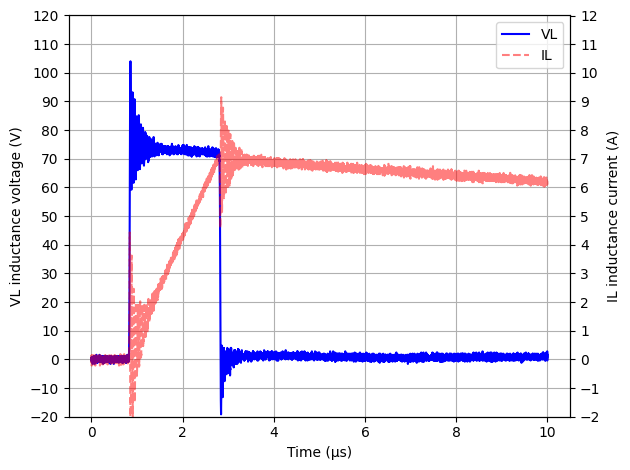

In [58]:
fig, ax1 = plt.subplots()
t = 1e6 * df.time.values
t = t - t[0]
line1, = ax1.plot(t, vds2, label='VL', c="b")
ax1.set_xlabel('Time (µs)')
ax1.set_ylabel('VL inductance voltage (V)')

ax2 = ax1.twinx()
line2, = ax2.plot(t, id2, linestyle='--', label='IL', c="r", alpha=0.5)
ax2.set_ylabel('IL inductance current (A)')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')
Imin, Imax=-2,12
Vmin,Vmax=-20,120
ax1.set_ylim([Vmin,Vmax])
ax2.set_ylim([Imin, Imax])
N=int((Vmax-Vmin)/10)+1
ax2.set_yticks(np.linspace(Imin, Imax, N))  
ax1.set_yticks(np.linspace(Vmin,Vmax, N))  

# X-axis ticks - simple approach
#ax1.set_xlim(0, 10)
ax1.xaxis.set_major_locator(plt.MultipleLocator(2))

ax1.grid()
plt.tight_layout()
plt.show()

In [59]:
# https://product.tdk.com/system/files/dam/doc/product/ferrite/ferrite/ferrite-core/data_sheet/80/db/fer/elp_43_10_28.pdf?ref_disty=mouser
# Combination: ELP 43/10/28 with ELP 43/10/28 N87
# Ae = 225 mm2
Ae = 225e-6
# le = 61.6 mm
le = 61.6e-3
AL = 7300e-9 #nH +/-25%
N = 8
integV= np.cumsum(vds2)*Ts


flux = integV/N
B = flux /Ae
H= N*id2/le

plt.plot

L = 21e-6
Bcal = L*id2/(Ae*N)
AL = L/N**2 # L= AL *N**2 
Lcal=L
ALcal=AL

#ALnom = 9600
#error =100*(AL*1e9-ALnom) /ALnom
#print ("AL (nH)= ", AL*1e9, "error %", error)


In [60]:
a="""
fig, axs = plt.subplots(1,2, figsize= (10,5))
axs[0].plot(vds2)
if len(idx_rise): 
    axs[0].plot(idx_rise, len(idx_rise)*[40], marker= "x")
if len(idx_fall): 
    axs[0].plot(idx_fall, len(idx_fall)*[60], marker= "x")
axs[1].plot(id2)
axs[0].grid()
axs[1].grid()"""

In [61]:
#Bcal<B.max()

In [62]:
#Bcal

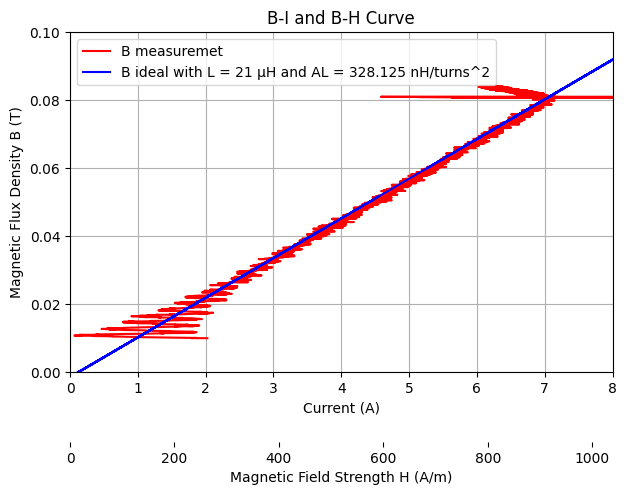

In [63]:


# Plot B vs Current with secondary x-axis for H (both at bottom)
fig, ax1 = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(bottom=0.2)
mask= B>0.01
ax1.plot(id2[mask], B[mask], label= "B measuremet", c="r")
ax1.set_xlabel('Current (A)')
ax1.set_ylabel('Magnetic Flux Density B (T)')
ax1.grid(True)
ax1.set_xlim([0,8])

i00=0.12
msk =Bcal<B.max()
msk =(Bcal>B.min()) & msk
#msk =Bcal<0.01
#[msk]
ax1.plot(id2+i00,Bcal, label= f"B ideal with L = {Lcal*1e6:.0f} µH and AL = {1e9*ALcal:.3f} nH/turns^2",c="b")
ax1.legend()

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim()[0] * N / le, ax1.get_xlim()[1] * N / le)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 50))
ax2.set_xlabel('Magnetic Field Strength H (A/m)')
ax2.set_frame_on(False)
ax1.set_ylim([0,0.1])
plt.title('B-I and B-H Curve')
plt.show()

**Estimating the real air gap**

The characterized inductance is 21 µH, while the estimated value using the measured AL and the nominal air gap is 21.77µH. Let's now estimate the actual air gap.

In [64]:
%%render 
AL_MeasNoAirGap  = 580e3/N**2 # nH/Turns2
AL_MeasAirGap = 21*1e3/N**2 # nH/Turns2

<IPython.core.display.Latex object>

In [65]:
%%render 
lg = 1e3 * mu_0 * Ae * 1e9*(1/AL_MeasAirGap - 1/AL_MeasNoAirGap) # mm
lg_nom = 0.8 # mm
lg_error = 100* (lg -lg_nom) /lg_nom # \%

<IPython.core.display.Latex object>

the air gap error of ~4% (800µm) is acceptable for plastic air gap without no control of the assembling pression

### The final result of Lr, Lm 

The double-pulse method is used as the reference technique for characterizing the resonant inductance (Lr) and magnetizing inductance (Lm). Additional complementary methods are also presented in this document.
The reference values are defined as follows:
* **Lr = 21 µH** (see double-pulse test for Lr with air gap)
* **Lm = 83 µH** (see double-pulse test for Lm with air gap)


## Resonant-circuit-based measurement method

### Setup

For this test, we will characterize the inductance using the LC resonance method. 

The setup and the key formulas required for the characterization are shown below.

In [66]:
fig_counter=One_figure_with_captions(fig_counter, img1="Setup3.png"
                                     , caption1="Overview of the setup (schematic)",
                                     first_part_path="figs/", 
                                     width=19)

In [67]:
fig_counter=One_figure_with_captions(fig_counter, img1="setup3_im.jpg"
                                     , caption1="Overview of the setup (Image)", 
                                     first_part_path="figs/", 
                                     width=15)

In [68]:
fig_counter=show_figure_pair_with_captionsOLD(
    fig_counter, 
    img1="insul1.jpg", 
    caption1="Insulation transformator",
    img2="relay.jpg", 
    caption2="Used relay", 
    first_part_path="figs/")

In [69]:

fig_counter=One_figure_with_captions(fig_counter, img1="2026-01-12_17-05-29-193.png"
                                     , caption1="Oscilloscope screenshot example", 
                                     first_part_path="05_LLC_resonance/", 
                                     width=15)

<u>**FORMULAS**</u>

In an ideal **LC** resonance circuit, the peak current in the inductor can be controlled by two factors: the capacitor value and its initial charging voltage, meaning the total initial energy stored in the capacitor. 

The goal is to estimate the inductance using theoretical calculation or small‑signal measurements, and then select the capacitor **C** and the initial voltage **V0** to achieve the desired peak current and resonance frequency. 

Both current and frequency are key for inductance characterization. The formulas are shown below:

**Ideal LC:**

In [70]:
L= 1
C=1 
V_0=1
I_peak =1

The energy stored in the capacitor and in the inductor at their respective maximum energy points:

In [71]:
%%render symbol
E_C= 1/2*C *V_0**2
E_L= 1/2 *L *I_peak **2 


<IPython.core.display.Latex object>

Since no resistor, so: 

In [72]:
%%render symbol
E_L =  E_L 


<IPython.core.display.Latex object>

So, we can calculate the peak current using: 

In [73]:
%%render symbol
I_peak = V_0*sqrt(C/L) 

<IPython.core.display.Latex object>

And the frequency will be approximately equal to the ideal resonance frequency given by:

In [74]:
%%render symbol
F_res0 = 1/(2*pi *sqrt(L*C))
omega_0 = 1/(sqrt(L*C))

<IPython.core.display.Latex object>

**With resistor (dumping): LCR**

In [75]:
R= 1

Dumping factor: 

In [76]:
%%render symbol
m = (R/2)*sqrt(C/L)

<IPython.core.display.Latex object>

Alpha: 

In [77]:
%%render symbol
alpha = omega_0*m

<IPython.core.display.Latex object>

Dumping frequency:

In [78]:
%%render symbol
F_resd = F_res0*sqrt(1 - m*m)
omega_d = omega_0*sqrt(1 - m*m)

<IPython.core.display.Latex object>

And the capacitor voltage : 

In [79]:
V_0=1
t=1
phase = 1

In [80]:
%%render symbol
V_0*exp(- alpha * t )*sin(omega_d*t-phase)

<IPython.core.display.Latex object>

### Current measurement methodes

In this sub‑section, we will take advantage of the test to verify a few current measurement methods.

If you want only inductance caracterisation, go to the next title (Lr+Lm). 

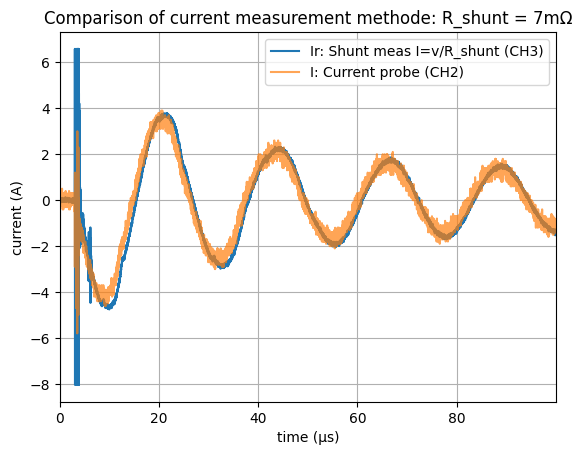

In [81]:
import pandas as pd
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-47-35-714.csv")
I = df.CH2.values
v= -df.CH3.values
R = 0.007

Ts= df.Ts.iloc[0]
time  =np.arange(0, len(I)*Ts, Ts)
I = I-I[:300].mean()
v = v-v[:300].mean()
plt.plot(time*1e6, v/R, label= "Ir: Shunt meas I=v/R_shunt (CH3)")#, c=rd)
plt.plot(time*1e6, I, alpha = 0.7, label= "I: Current probe (CH2)")#, c=bl)
plt.legend()
plt.xlabel("time (µs)")
plt.ylabel("current (A)")
plt.xlim([0, 1e6*time.max()])
plt.grid()
plt.title("Comparison of current measurement methode: R_shunt = 7mΩ")
plt.show()

In [82]:
I = I[1000:]
v = v[1000:]
time= time[1000:]

Above is the full signal, and below is only 90% of the signal to avoid the initial transient phase.

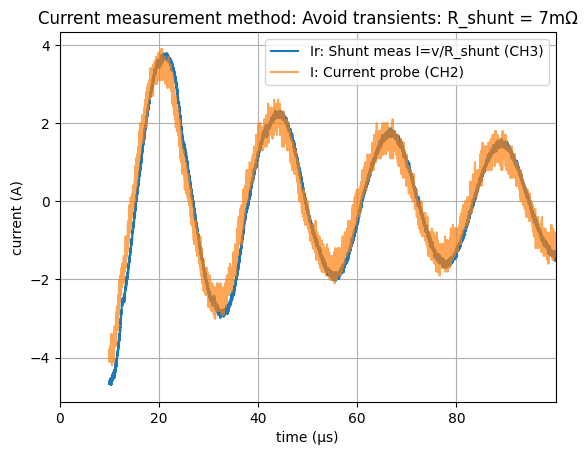

In [83]:
plt.plot(time*1e6, v/R, label= "Ir: Shunt meas I=v/R_shunt (CH3)")#, c=rd)
plt.plot(time*1e6, I, alpha = 0.7, label= "I: Current probe (CH2)")#, c=bl)
plt.legend()
plt.xlabel("time (µs)")
plt.ylabel("current (A)")
plt.xlim([0, 1e6*time.max()])
plt.grid()
plt.title("Current measurement method: Avoid transients: R_shunt = 7mΩ")
plt.show()

In [84]:
import numpy as np
from scipy import signal

fs = 1 / Ts          # sampling frequency
fc = 5e6          # cutoff frequency (Hz)
order = 4

# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')

# zero-phase filtering
I2= signal.sosfiltfilt(sos, I)

Below is some advanced preprocessing: 

for the TCP202 current probe, we apply a non‑causal zero‑phase filter with a 5 MHz cutoff frequency, and for the shunt measurement, we introduce a −0.6 µs delay to compensate for the phase shift introduced by the signal transformer.

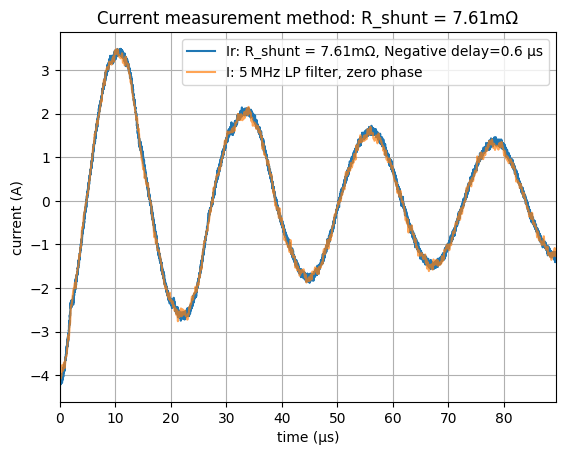

In [85]:
n=60
Ir = v/R
k=0.92
I22=I2[:-n]-0.08
Ir2 =  k*Ir[n:]

time  =np.arange(0, len(I22)*Ts, Ts)



plt.plot(time*1e6, Ir2, label= "Ir: R_shunt = 7.61mΩ"+f", Negative delay={n*Ts*1e6} µs")#, c=rd)
plt.plot(time*1e6, I22, alpha = 0.7, label= "I: 5 MHz LP filter, zero phase")#, c=bl)
plt.legend()
plt.xlabel("time (µs)")
plt.ylabel("current (A)")
plt.xlim([0, 1e6*time.max()])
plt.grid()
plt.title("Current measurement method: R_shunt = 7.61mΩ")
plt.show()

**Conclusion**

A shunt combined with a signal transformer can be used as a fast current probe, but this setup introduces a relatively large delay of about 600 ns.

**Using capacitor voltage to estimate the current**

below we will check this methode: 

In [86]:
vc = df.CH1.values
vc = vc[1000:]
time = 1e6*df.time.values[1000:]

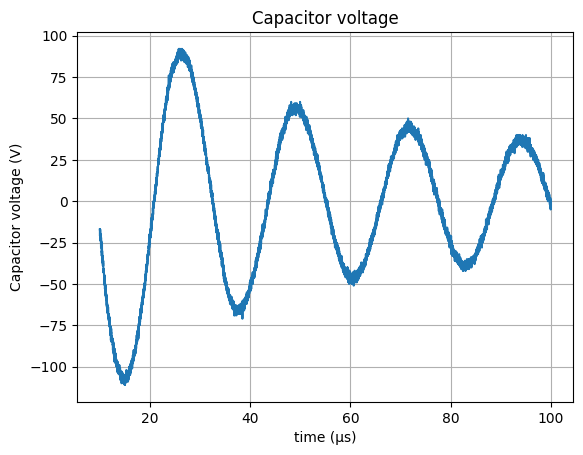

In [87]:
plt.plot(time,vc)

#plt.legend()
plt.xlabel("time (µs)")
plt.ylabel("Capacitor voltage (V)")
#plt.xlim([0, time.max()])
plt.grid()
plt.title("Capacitor voltage")
plt.show()

Below the comparaison between the probe current (TCP202) and the estimated current using the capacitor voltage derivation

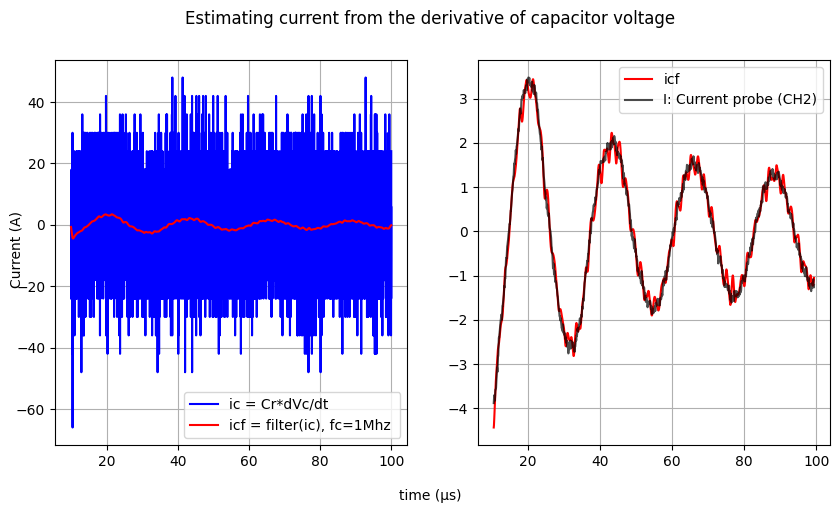

In [88]:
fig, axs = plt.subplots(1,2, figsize =(10,5))
axs=axs.flatten()


#time  =1e6*np.arange(0, len(vc)*Ts, Ts)

Cr = 120e-9
#ic = Cr*np.diff(vc)/Ts
#ic = np.append(ic, 0)  
ic= Cr*np.gradient(vc, Ts)
# i = c*dv/dt
axs[0].plot(time, ic, c="b", label = "ic = Cr*dVc/dt")


fs = 1 / Ts          # sampling frequency
fc =1e6          # cutoff frequency (Hz)
order = 4

# design filter
sos = signal.butter(order, fc, btype='low', fs=fs, output='sos')

# zero-phase filtering
ic2= signal.sosfiltfilt(sos, ic)
axs[0].plot(time, ic2, c="r", label = "icf = filter(ic), fc=1Mhz ")

#plt.plot(ic2)


I22=I2[n:-n]-0.08
ic22=ic2[n:-n]
#Ir2 =  k*Ir[n:]
axs[1].plot(time[n:-n], ic22, c="r", label="icf")
axs[1].plot(time[n:-n], I22, c="k", alpha=0.7, label= "I: Current probe (CH2)")

#plt.plot(Ir2, alpha =0.7)
fig.suptitle("Estimating current from the derivative of capacitor voltage")

axs[1].grid()
axs[0].grid()

axs[1].legend()
axs[0].legend()

# Shared labels
fig.text(0.5, 0, 'time (µs)', ha='center')   # X-axis label
fig.text(0.08, 0.5, 'Current (A)', va='center', rotation='vertical')  # Y-axis label

plt.show()

**Conclusion**

Capacitor‑voltage derivation is a valid method when combined with preprocessing using a non‑causal zero‑phase filter, as illustrated above. The raw derivative signal is unusable (see the blue curve). 

However, using a 1 MHz low‑pass filter limits the current‑measurement bandwidth. Therefore, this approach can serve as an alternative when direct measurement is not feasible.

### Lr+Lm

In this test, we will use the damping formulas presented in the setup section. The idea is to adjust L, C, and R until we obtain the best fit between the measured curve and the theoretical response of the damped LRC circuit, allowing us to determine the inductance L. 

As a complementary method, we will also compute the resonance frequency to extract the characterized value of L.

**Initial value**

In [89]:
%%render params 1
Lm_uH=83 # µH
Lr_uH=21 # µH
Cr_nF =120 # nF

<IPython.core.display.Latex object>

**Tuned values**

In [90]:
%%render params 1
Lm_uH=79 # µH
Lr_uH=24.5 # µH
Cr_nF =124.8 # nF
R=3.4 # Ω

<IPython.core.display.Latex object>

Total inductance

In [91]:
%%render 1
L_uH = Lm_uH + Lr_uH # uH

<IPython.core.display.Latex object>

In [92]:
L = L_uH*1e-6

title=f"Comparison: Measurements vs Theoretical series LCR circuit\n"+\
f"L=Lr+Lm={L*1e6}µH; C=Cr={Cr_nF}nF; R={R}Ω"

In [93]:
V0=pd.read_csv("05_LLC_resonance/2026-01-12_17-39-34-446.csv").CH1.mean()

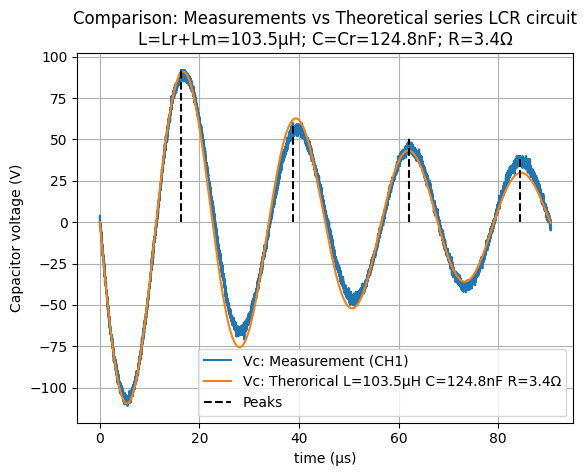

In [94]:
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-47-35-714.csv")
#pd.read_csv("05_LLC_resonance/2026-01-12_17-47-35-714.csv")
Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]


#Cr_nF =120
def dumpsin(t, Y0=10, phase = 0, L=L,C=Cr_nF*1e-9,R=R):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
#vc2= dumpsin(time,  Y0=-120, phase = 0, L=(79+24.5)*1e-6,C=1.04*120e-9,R=R)
vc2= dumpsin(time,  Y0=-120, phase = 0, L=L,C=Cr_nF*1e-9,R=R)
plt.title(title)
time=time*1e6
plt.plot(time, vc, label="Vc: Measurement (CH1)")
plt.plot(time, vc2, label ="Vc: Therorical "+f"L={L_uH}µH C={Cr_nF}nF R={R}Ω")

plt.grid()
plt.xlabel("time (µs)")
plt.ylabel("Capacitor voltage (V)")

cond= True
from scipy.signal import find_peaks
inPeaks, properties = find_peaks(vc, height=0.5, distance=1000)
#mpeak = max(peak_values)
Peaks = properties["peak_heights"]
for P,i in zip(Peaks[1:], inPeaks[1:]): 
    if cond:
        cond = False
        plt.plot([time[i],time[i]], [0,P], c="k", linestyle="--", label="Peaks")
        
    else: 
        
        plt.plot([time[i],time[i]], [0, P], c="k", linestyle="--")

plt.legend()
plt.show()


In [95]:
i1= inPeaks[1]
i2= inPeaks[-1]
Fr= 3/((i2-i1)*Ts)
print(f"Resonant frequency estimated from the average peak interval (see above): Fr = {Fr*1e-3:.2f} kHz")

Resonant frequency estimated from the average peak interval (see above): Fr = 44.08 kHz


Theoretical resonant frequency calculated from the L and C values:

In [96]:
%%render 10
C = Cr_nF*1e-9

<IPython.core.display.Latex object>

In [97]:
%%render 
Fr = 1e-3/(2*pi*sqrt(L*Cr_nF*1e-9)) # khz 

<IPython.core.display.Latex object>

In [98]:
#%%render 
#m = (R/2)*sqrt(C/L)

In [99]:
%%render 
m = (R/2)*sqrt(C/L) # damping factor
FreqD_theo = Fr*sqrt(1 - m*m) # kHz, damped frequency

<IPython.core.display.Latex object>

In [100]:
%%render 
FreqD_meas = 44.08
Freq_Error = 100*(FreqD_meas-FreqD_theo) /FreqD_theo # \%

<IPython.core.display.Latex object>

The error between the tuned resonant LRC frequency and the average measured value is 0.3%, which indicates a very good estimation.

### Lr

**Tuned values**

In [101]:
%%render params
Lr_uH=24.5 # µH
Cr_nF =Cr_nF # nF
R=0.4 # Ω

<IPython.core.display.Latex object>

In [102]:
L = (Lr_uH)*1e-6

title=f"Comparison: Measurements vs Theoretical series LCR circuit\n"+\
f"L=Lr={L*1e6}µH; C=Cr={Cr_nF}nF; R={R}Ω"

In [103]:
#V0=pd.read_csv("05_LLC_resonance/2026-01-12_17-39-34-446.csv").CH1.mean()

In [104]:
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-30-26-003.csv")

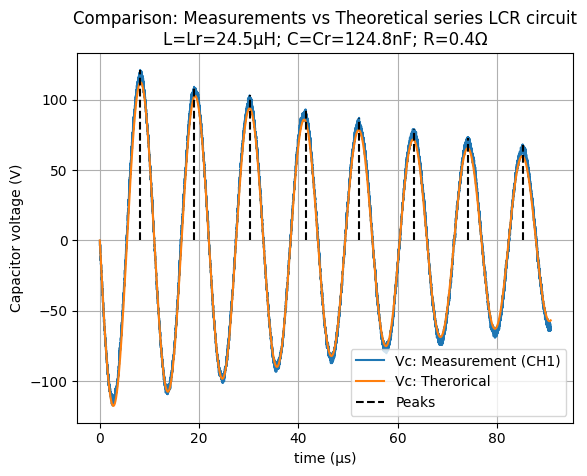

In [105]:

Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]


#Cr_nF =120
def dumpsin(t, Y0=10, phase = 0, L=L,C=Cr_nF*1e-9,R=R):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
#vc2= dumpsin(time,  Y0=-120, phase = 0, L=(79+24.5)*1e-6,C=1.04*120e-9,R=R)
vc2= dumpsin(time,  Y0=-120, phase = 0, L=L,C=Cr_nF*1e-9,R=R)
#vc2= dumpsin(time,  Y0=-125, phase = 0, L=(24.5)*1e-6,C=1.04*120e-9,R=0.4)
plt.title(title)

plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)")
plt.plot(time*1e6, vc2, label ="Vc: Therorical")
#plt.legend()
plt.grid()
plt.xlabel("time (µs)")
plt.ylabel("Capacitor voltage (V)")



from scipy.signal import find_peaks
inPeaks, properties = find_peaks(vc, height=0.5, distance=1000)
#mpeak = max(peak_values)
Peaks = properties["peak_heights"]
for P,i in zip(Peaks[:], inPeaks[:]): 
    if i < inPeaks[-1]:
        plt.plot([time[i]*1e6,time[i]*1e6], [0, P], c="k", linestyle="--")
    else: 
        plt.plot([time[i]*1e6,time[i]*1e6], [0,P], c="k", linestyle="--", label="Peaks")

plt.legend()
plt.show()



In [106]:
i1= inPeaks[0]
i2= inPeaks[-1]
Fr= (len(inPeaks)-1)/((i2-i1)*Ts)
print(f"Resonant frequency estimated from the average peak interval (see above): Fr = {Fr*1e-3:.2f} kHz")

Resonant frequency estimated from the average peak interval (see above): Fr = 90.77 kHz


Theoretical resonant frequency calculated from the L and C values:

In [107]:
%%render 9
C = Cr_nF*1e-9

<IPython.core.display.Latex object>

In [108]:
%%render 
Fr = 1e-3/(2*pi*sqrt(L*Cr_nF*1e-9)) # khz 

<IPython.core.display.Latex object>

In [109]:
%%render 4
m = (R/2)*sqrt(C/L) # damping factor
FreqD_theo = Fr*sqrt(1 - m*m) # kHz, damped frequency

<IPython.core.display.Latex object>

The damped frequency erorr: 

In [110]:
%%render 
FreqD_meas = 90.77
Freq_Error = 100*(FreqD_meas-FreqD_theo) /FreqD_theo # \%

<IPython.core.display.Latex object>

The error between the tuned resonant LRC frequency and the average measured value is 0.3%, which indicates a very good estimation.

### Lm 

**Tuned values**

In [111]:
%%render params
Lm_uH=Lm_uH # µH
Cr_nF =Cr_nF # nF
R=3 # Ω

<IPython.core.display.Latex object>

In [112]:
L = (Lm_uH)*1e-6

title=f"Comparison: Measurements vs Theoretical series LCR circuit\n"+\
f"L=Lr={L*1e6}µH; C=Cr={Cr_nF}nF; R={R}Ω"

In [113]:
#V0=pd.read_csv("05_LLC_resonance/2026-01-12_17-39-34-446.csv").CH1.mean()

In [114]:
df = pd.read_csv("05_LLC_resonance/2026-01-12_17-37-55-165.csv")

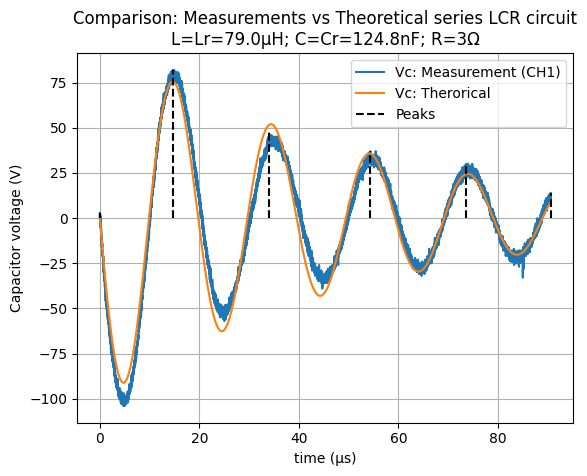

In [115]:

Ts= df.Ts.iloc[0]

vc = df.CH1.values #-v0
idx= trigger(vc, transition='fall', thresh=0)[0]

vc= vc[idx:]


#Cr_nF =120
def dumpsin(t, Y0=10, phase = 0, L=L,C=Cr_nF*1e-9,R=R):

    w0 = 1/np.sqrt(L*C)
    m = (R/2)*np.sqrt(C/L)
    
    alpha = w0*m
    wd = w0*np.sqrt(1 - m*m)   # damped oscillation frequency

    return Y0*np.exp(-alpha*t)*np.sin(wd*t-phase)
time  =np.arange(0, len(vc)*Ts, Ts)
#vc2= dumpsin(time,  Y0=-120, phase = 0, L=(79+24.5)*1e-6,C=1.04*120e-9,R=R)
vc2= dumpsin(time,  Y0=-100, phase = 0, L=L,C=Cr_nF*1e-9,R=R)
#vc2= dumpsin(time,  Y0=-125, phase = 0, L=(24.5)*1e-6,C=1.04*120e-9,R=0.4)
#vc2= dumpsin(time,  Y0=-100, phase = 0, L=(79)*1e-6,C=1.04*120e-9,R=3)
plt.title(title)

plt.plot(time*1e6, vc, label="Vc: Measurement (CH1)")
plt.plot(time*1e6, vc2, label ="Vc: Therorical")
#plt.legend()
plt.grid()
plt.xlabel("time (µs)")
plt.ylabel("Capacitor voltage (V)")



from scipy.signal import find_peaks
inPeaks, properties = find_peaks(vc, height=0.5, distance=1000)
#mpeak = max(peak_values)
Peaks = properties["peak_heights"]
for P,i in zip(Peaks[:], inPeaks[:]): 
    if i < inPeaks[-1]:
        plt.plot([time[i]*1e6,time[i]*1e6], [0, P], c="k", linestyle="--")
    else: 
        plt.plot([time[i]*1e6,time[i]*1e6], [0,P], c="k", linestyle="--", label="Peaks")

plt.legend()


plt.show()



In [116]:
i1= inPeaks[1]
i2= inPeaks[-2]
Fr= 3/((i2-i1)*Ts)
print(f"Resonant frequency estimated from the average peak interval (see above): Fr = {Fr*1e-3:.2f} kHz")

Resonant frequency estimated from the average peak interval (see above): Fr = 50.84 kHz


Theoretical resonant frequency calculated from the L and C values:

In [117]:
%%render 10
C = Cr_nF*1e-9

<IPython.core.display.Latex object>

In [118]:
%%render 
Fr = 1e-3/(2*pi*sqrt(L*Cr_nF*1e-9)) # khz 

<IPython.core.display.Latex object>

In [119]:
%%render 
m = (R/2)*sqrt(C/L) # damping factor
FreqD_theo = Fr*sqrt(1 - m*m) # kHz, damped frequency

<IPython.core.display.Latex object>

The damped frequency erorr: 

In [120]:
%%render 
FreqD_meas = 50.84
Freq_Error = 100*(FreqD_meas-FreqD_theo) /FreqD_theo # \%

<IPython.core.display.Latex object>

The error between the tuned resonant LRC frequency and the average measured value is 0.5%, which indicates a very good estimation.

### Why is it difficult to fit the LRC curve?

**Reminder of the damping formulas for a series LCR circuit**

In [121]:
R= 1

Dumping factor: 

In [122]:
%%render symbol
m = (R/2)*sqrt(C/L)

<IPython.core.display.Latex object>

Alpha: 

In [123]:
%%render symbol
alpha = omega_0*m

<IPython.core.display.Latex object>

Dumping frequency:

In [124]:
%%render symbol
F_resd = F_res0*sqrt(1 - m*m)
omega_d = omega_0*sqrt(1 - m*m)

<IPython.core.display.Latex object>

And the capacitor voltage : 

In [125]:
V_0=1
t=1
phase = 1

In [126]:
%%render symbol
V_0*exp(- alpha * t )*sin(omega_d*t-phase)

<IPython.core.display.Latex object>

This formula assumes that L, R, and C are constant over all voltage–current operating points, which is not accurate:

*   **L:** inductance drops with increasing current due to magnetic saturation
*   **R:** this is critical because R models the core losses, which strongly depend on voltage and flux density—higher current results in higher losses and thus a larger effective R
*   **C:** capacitance changes slightly with voltage and tends to decrease as voltage rises, although this remains a secondary effect


## Small-signal characterization

### Setup

The below illustrated setup is simplified. In the actual implementation, the original DC-DC PCB was utilized with the primary and secondary MOSFETs removed. An isolated 12 V battery was inserted in series with the function generator to prevent any bootstrap capacitor loop interaction. Under these conditions, the bootstrap diode remains reverse-biased, ensuring effective isolation of the bootstrap capacitor from the measurement circuit.

In [127]:
fig_counter=One_figure_with_captions(fig_counter, img1="Setup2.png"
                                     , caption1="Small-signal characterization setup",
                                     first_part_path="figs/", 
                                     width=19)

The reference values of L, C, R...: 

In [128]:
%%render params 
Lr_uH = 21 #uH
Lm_uH= 83# uH
Cr_nF = 120# nF
n=4
R_load= 1963 # Ω

<IPython.core.display.Latex object>

Calculate the Ln, Fr

In [129]:
%%render long
Ln= Lm_uH/Lr_uH
Fr_khz= 1e-3/(2*pi*sqrt(1e-6*Lr_uH*1e-9*Cr_nF)) # kHz

<IPython.core.display.Latex object>

Calculate the equivalent load in primary side

In [130]:
%%render 0
Re = R_load*(n/2)**2

<IPython.core.display.Latex object>

The quality factor of the LLC 

In [131]:
%%render 5
Qe= sqrt(1e3*Lr_uH/Cr_nF)/Re 

<IPython.core.display.Latex object>

Below are the measured values for the frequency, the primary peak‑to‑peak voltage, and the composed secondary voltage.

the gain `G` is calculated using the formula:

In [132]:
CH2_pp, CH1_pp=1, 1

In [133]:
%%render symbol
G= 0.5* n*(CH2_pp/2)/CH1_pp 

<IPython.core.display.Latex object>

$\frac{ \mathrm{CH2}_{pp} }{ 2 }$ because the secondary voltage is composed (2 secondary winding : see the setup)

0.5 because of the half‑bridge architecture

So: 

In [134]:
%%render symbol
G = CH2_pp/CH1_pp

<IPython.core.display.Latex object>

<u>**Load ~2kΩ:**</u>

In [135]:
# Charge = 1963 ohm 
t= """Freqkhz	CH1pp	CH2pp
162.1	8.45	6.52
151.7	8.25	6.46
139.9	7.95	6.42
129.4	7.65	6.34
121.3	7.4	6.22
109.9	7.2	6.12
101.7	6.65	6
90.93	6	5.76
80.99	5.02	5.52
70.35	3.98	5.22
61.25	2.78	4.8
50	1.11	4.24
47	0.42	4
42	1.05	3.52
37	2.2	3.12""".split("\n")
t= [x.split('\t') for x in t]
df= pd.DataFrame(t[1:], columns = t[0])
df = df.astype("float64")
df['Load_ohm']= 1963
df["G"]= (df["CH2pp"]/df["CH1pp"]).round(3)

dfa1=df.copy()
df

,Freqkhz,CH1pp,CH2pp,Load_ohm,G
0,162.10,8.45,6.52,1963,0.772
1,151.70,8.25,6.46,1963,0.783
2,139.90,7.95,6.42,1963,0.808
3,129.40,7.65,6.34,1963,0.829
4,121.30,7.40,6.22,1963,0.841
5,109.90,7.20,6.12,1963,0.850
6,101.70,6.65,6.00,1963,0.902
7,90.93,6.00,5.76,1963,0.960
8,80.99,5.02,5.52,1963,1.100
9,70.35,3.98,5.22,1963,1.312


 **Reminder: The theoretical gain formula**

<!--img src="./02_simulation/Schematic1.png" style="width:19cm;"-->


<br>

The voltage gain function (normalized) expression is:

$$
M_g = \left| \frac{L_n \cdot f_n^2}{\left[(L_n + 1) \cdot f_n^2 - 1\right] + j\left[(f_n^2 - 1) \cdot f_n \cdot Q_e \cdot L_n\right]} \right|
$$

With:

$$
L_n = \frac{L_m}{L_r}, \quad Q_e = \frac{\sqrt{\frac{L_r}{C_r}}}{R_e}, \quad f_n = \frac{f_{sw}}{f_0}, \quad f_0 = \frac{1}{2\pi\sqrt{L_r C_r}}
$$


<br> <br>
Below is a comparison of the theoretical gain versus the measured gain.

In [136]:
#dfa["Freqkhz"]
def calculate_Mg(Ln, fn, Qe):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = abs(numerator / denominator)
    return Mg

In [137]:
#print(Qe)

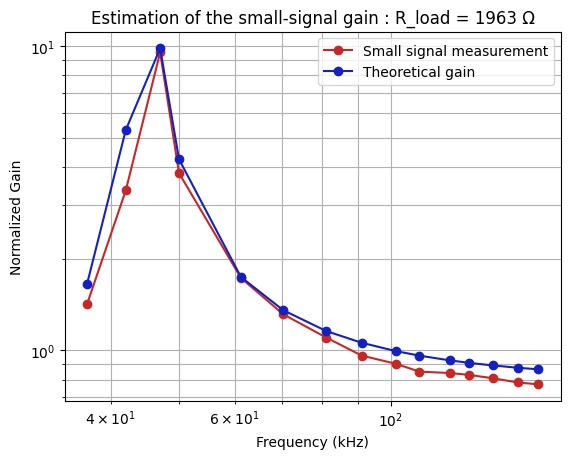

In [138]:
fn=fn=dfa1["Freqkhz"]/Fr_khz
#fn = np.arange(0.35,1.5,0.001)
#Lnc=3 
#Qe = 0.55 
#Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=Qe)
Mg= calculate_Mg(Ln=Ln, fn=fn, Qe=Qe)


dfa1.plot( x='Freqkhz', y="G", marker = "o", label = "Small signal measurement", c=rd)
#sns.lineplot(data= dfa1, x='Freqkhz', y="MgTheo2", hue = "Load_ohm")
plt.plot(dfa1["Freqkhz"], Mg, marker = "o", label="Theoretical gain", c=bl)
plt.xscale("log")
plt.yscale("log")
plt.grid(which = "both")
plt.legend()
#plt.plot(df35.F/1000, df35.Mg, marker = "x")

plt.ylabel("Normalized Gain")
plt.xlabel("Frequency (kHz)")
plt.title(f"Estimation of the small-signal gain : R_load = {R_load} Ω")
plt.show()

<u>**Load ~10.1Ω:**</u>

In [139]:
Qeold= Qe 
dfa1old = dfa1.copy()

In [140]:
%%render params 1
R_load= 10.1 # Ω

<IPython.core.display.Latex object>

In [141]:
%%render 2
Re = R_load*(n/2)**2

<IPython.core.display.Latex object>

In [142]:
%%render 3
Qe= sqrt(1e3*Lr_uH/Cr_nF)/Re 

<IPython.core.display.Latex object>

In [143]:
# Charge = 10.1 ohm 
t= """Freqkhz	CH1pp	CH2pp
160.6	5.3	3.74
151.8	5.2	3.74
141.4	5.05	3.78
131.3	4.85	3.74
121.6	4.46	3.76
110	4.2	3.78
101.2	4	3.72
90.55	3.72	3.66
80.42	3.28	3.64
70.31	2.8	3.52
61.93	2.24	3.44
52.38	1.48	3.05
49.74	1.45	2.99
42.19	1.89	2.69
36.3	2.86	2.38""".split("\n")
t= [x.split('\t') for x in t]
df= pd.DataFrame(t[1:], columns = t[0])
df = df.astype("float64")
df['Load_ohm']= 10.1
df["G"]= (df["CH2pp"]/df["CH1pp"]).round(3)

dfa1=df.copy()
dfa1

,Freqkhz,CH1pp,CH2pp,Load_ohm,G
0,160.60,5.30,3.74,10.1,0.706
1,151.80,5.20,3.74,10.1,0.719
2,141.40,5.05,3.78,10.1,0.749
3,131.30,4.85,3.74,10.1,0.771
4,121.60,4.46,3.76,10.1,0.843
5,110.00,4.20,3.78,10.1,0.900
6,101.20,4.00,3.72,10.1,0.930
7,90.55,3.72,3.66,10.1,0.984
8,80.42,3.28,3.64,10.1,1.110
9,70.31,2.80,3.52,10.1,1.257


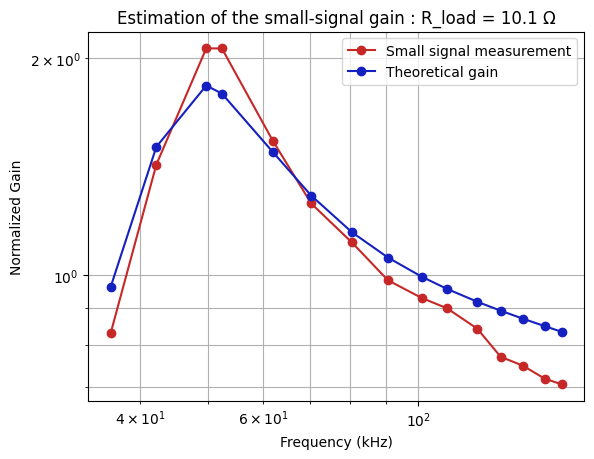

In [144]:
fn=fn=dfa1["Freqkhz"]/Fr_khz
#fn = np.arange(0.35,1.5,0.001)
#Lnc=3 
#Qe = 0.55 
#Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=Qe)
Mg= calculate_Mg(Ln=Ln, fn=fn, Qe=Qe)


dfa1.plot( x='Freqkhz', y="G", marker = "o", label = "Small signal measurement", c=rd)
#sns.lineplot(data= dfa1, x='Freqkhz', y="MgTheo2", hue = "Load_ohm")
plt.plot(dfa1["Freqkhz"], Mg, marker = "o", label="Theoretical gain", c=bl)
plt.xscale("log")
plt.yscale("log")
plt.grid(which = "both")
plt.legend()
#plt.plot(df35.F/1000, df35.Mg, marker = "x")

plt.ylabel("Normalized Gain")
plt.xlabel("Frequency (kHz)")
plt.title(f"Estimation of the small-signal gain : R_load = {R_load} Ω")
plt.show()

<u>**Comparing both load measurements**</u>

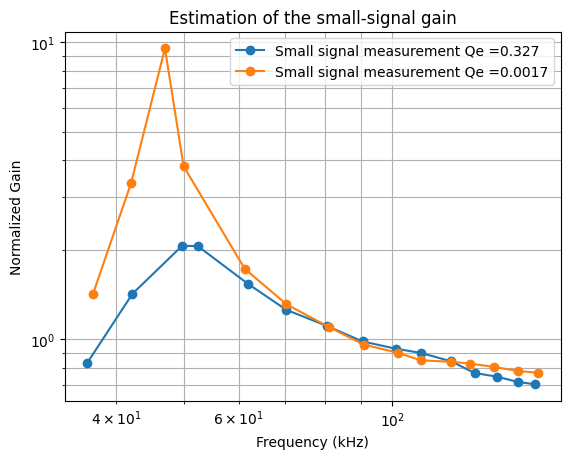

In [145]:
fn=fn=dfa1["Freqkhz"]/Fr_khz
#fn = np.arange(0.35,1.5,0.001)
#Lnc=3 
#Qe = 0.55 
Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=Qe)


dfa1.plot( x='Freqkhz', y="G", marker = "o", label = f"Small signal measurement Qe ={Qe:.3f}")#, c=rd)
#sns.lineplot(data= dfa1, x='Freqkhz', y="MgTheo2", hue = "Load_ohm")
#plt.plot(dfa1["Freqkhz"], Mg, marker = "o", label="Theoretical gain", c=bl)
plt.plot( dfa1old.Freqkhz, dfa1old.G, marker = "o",
          label = f"Small signal measurement Qe ={Qeold:.4f}")#, c=bl)

plt.xscale("log")
plt.yscale("log")
plt.grid(which = "both")
plt.legend()
#plt.plot(df35.F/1000, df35.Mg, marker = "x")

plt.ylabel("Normalized Gain")
plt.xlabel("Frequency (kHz)")
plt.title(f"Estimation of the small-signal gain")
plt.show()

## Operational gain measurement

### Setup 

In this test, we will operate the full LLC DC‑DC converter using software that enables manual frequency adjustment via a potentiometer (see the setup below). 

With the input voltage fixed, we will start at the maximum frequency and then reduce it progressively down to the minimum value.

In [146]:

fig_counter=One_figure_with_captions(fig_counter, img1="Setup4.png"
                                     , caption1="Operational gain measurement setup",
                                     first_part_path="figs/", 
                                     width=19)

### Results

In [147]:
#dfa["Freqkhz"]
def calculate_Mg(Ln, fn, Qe):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = abs(numerator / denominator)
    return Mg

**The input values**

In [148]:
%%render params 1
Lm_uH=83 # µH
Lr_uH=21 # µH
Cr_nF =120 # nF
n=4 # Transformator
Rload=22 # Ω
Vin = 345 # V

<IPython.core.display.Latex object>

**Calculation of LLC tank parameters**

In [149]:
%%render 
Ln = Lm_uH/Lr_uH
Re = 8*n**2*Rload / (pi**2) # Ω
Qe = sqrt(1e3*Lr_uH/Cr_nF)/Re
Fr = 1/(2*pi*(sqrt(Lr_uH*1e-9*Cr_nF))) # kHz

<IPython.core.display.Latex object>

In [150]:
Vout = 48

We will use this formula to compute the gain. Throughout the document, the gain is indicated either as G or Mg, both referring to the same quantity.

In [151]:
%%render symbolic 
Mg = n*Vout/(Vin/2)

<IPython.core.display.Latex object>

In [152]:
t= """155	37.3
147	37.7
121	38.55
110.9	40.48
91.25	44.19
79.91	47.02
77.83	48.88""".split("\n")
t=[x.split("\t") for x in t]
df= pd.DataFrame(t, columns =["FreqKHz", "Vout"]).astype("float64")
#df["FreqKHz"]=df["F"]*1000
df["Mg"]= n*df["Vout"]/(Vin /2)
df

,FreqKHz,Vout,Mg
0,155.00,37.30,0.864928
1,147.00,37.70,0.874203
2,121.00,38.55,0.893913
3,110.90,40.48,0.938667
4,91.25,44.19,1.024696
5,79.91,47.02,1.090319
6,77.83,48.88,1.133449


/!\ : Starting from 80 kHz, an audible noise appears, and at 75 kHz all MOSFETs fail. This happens because ZVS is lost, causing very high losses in the primary MOSFETs and leading to a cascade of failures. 

All primary/seconday mosfets are replaced. 

In the future, we will limit the minimum operating frequency near the resonance point to avoid this issue (around 95 kHz).

Below is a comparison of the theoretical gain VS the measured gain.

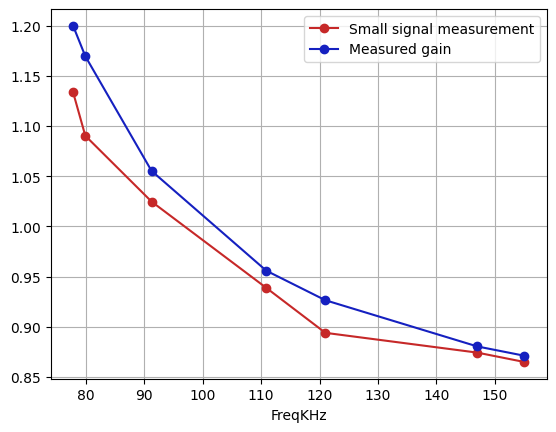

In [153]:
fn=df["FreqKHz"].values/Fr_khz
#fn = np.arange(0.35,1.5,0.001)
#Lnc=3 
#Qe = 0.55 
#Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=Qe)
Mg= calculate_Mg(Ln=Ln, fn=fn, Qe=Qe)


df.plot( x='FreqKHz', y="Mg", marker = "o", label = "Small signal measurement", c=rd)
#sns.lineplot(data= dfa1, x='Freqkhz', y="MgTheo2", hue = "Load_ohm")
plt.plot(df["FreqKHz"].values, Mg, marker = "o", label="Measured gain", c=bl)
#plt.xscale("log")
#plt.yscale("log")
plt.grid(which = "both")
plt.legend()
#plt.plot(df35.F/1000, df35.Mg, marker = "x")

#plt.ylabel("Normalized Gain")
#plt.xlabel("Frequency (kHz)")
#plt.title(f"Estimation of the small-signal gain : R_load = {R_load} Ω")
plt.show()

In [154]:
import numpy as np
from scipy.optimize import minimize


def calculate_Mg22(Ln, fn, Qe, K=1):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = K*abs(numerator / denominator)
    return Mg

    
# initial guess
K=1
x0 = [Ln, Qe, K]
Mg= df["Mg"].values
def obj (Ln , Qe, K): 
    Mgcal = calculate_Mg22(Ln, fn, Qe, K)
    return np.abs(Mgcal-Mg).sum()
    
# wrapper for 3 parameters
def obj_wrap(x):
    Ln_, Qe_, K_ = x
    return obj(Ln_, Qe_, K_)

# bounds (strongly recommended)
bounds = [
    (0.01, 50),     # Ln
    (1e-4, 10),     # Qe
    (0.01, 10)      # K
]

# optimization
res = minimize(
    obj_wrap,
    x0,
    method="Powell",     # stable for non-linear problems
    bounds=bounds
)

Ln_opt, Qe_opt, K_opt = res.x

_="""
print("Ln_opt =", Ln_opt)
print("Qe_opt =", Qe_opt)
print("K_opt  =", K_opt)
print("Objective =", res.fun)
"""

Let's try to estimate a correction to the theoretical gain to match the measurement by adjusting the quality factor **Qe**, the normalized inductance **Ln**, and a multiplicative factor **K**.

The multiplicative factor applies as follows: : Mg_opt = k * Mg

After runing the optimization python algorithm `scipy.optimize import minimize`: 

In [155]:
pd.DataFrame([{"Qe":Qe, "Ln":Ln, "k":1}, 
 {"Qe":Qe_opt, "Ln":Ln_opt, "k":K_opt}], 
             index = ["Initial values", "Optimized values"]
            ).T.round(3)# apply(lambda x:np.round(x,1))

,Initial values,Optimized values
Qe,0.046,0.084
Ln,3.952,4.674
k,1.000,0.975


In [156]:
Mg= calculate_Mg(Ln=Ln, fn=fn, Qe=Qe)
Mg2 = calculate_Mg22(Ln_opt, fn, Qe_opt, K_opt)

Below the comparaison

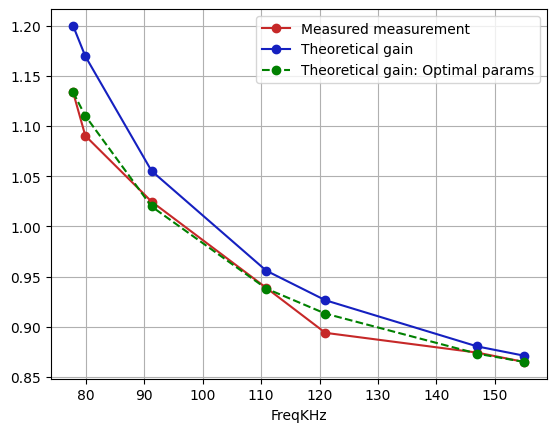

In [157]:
Mg= calculate_Mg(Ln=Ln, fn=fn, Qe=Qe)


df.plot( x='FreqKHz', y="Mg", marker = "o", label = "Measured measurement", c=rd)
#sns.lineplot(data= dfa1, x='Freqkhz', y="MgTheo2", hue = "Load_ohm")
plt.plot(df["FreqKHz"].values, Mg, marker = "o", label="Theoretical gain", c=bl)
#plt.xscale("log")
#plt.yscale("log")
plt.grid(which = "both")

#plt.plot(df35.F/1000, df35.Mg, marker = "x")

#plt.ylabel("Normalized Gain")
#plt.xlabel("Frequency (kHz)")

#plt.title(f"Estimation of the small-signal gain : R_load = {R_load} Ω")


Mg= calculate_Mg(Ln=Ln_opt, fn=fn, Qe=Qe_opt)
plt.plot(df["FreqKHz"].values, K_opt*Mg, marker = "o", 
         label="Theoretical gain: Optimal params", c="g", linestyle= "--")

plt.legend()
plt.show()

## Conclusion

As noted in the beginning, the reference values for both the transformer inductance and the resonant inductance will be based on the results of the single‑pulse test.

In [158]:
%%render params 1
Lm_uH=83 # µH
Lr_uH=21 # µH
#Cr_nF =120 # nF

<IPython.core.display.Latex object>